<a href="https://colab.research.google.com/github/mhawkes2/AML/blob/main/Hawkes_Natural_Language_Processing_with_Disaster_Tweets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries & Load Dataset

In [ ]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

import nltk
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.probability import FreqDist

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import KFold, GridSearchCV, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Download libraries
for pkg in ["punkt", "stopwords", "wordnet", "omw-1.4", "punkt_tab"]:
    nltk.download(pkg, quiet=True)

sns.set(context='notebook', style='whitegrid')

In [ ]:
# Load the datasets
test_data = pd.read_csv('/content/test.csv')
train_data = pd.read_csv('/content/train.csv')

# Display the first few rows of each dataset to understand their structure
train_data.head(), test_data.head()

(   id keyword location                                               text  \
 0   1     NaN      NaN  Our Deeds are the Reason of this #earthquake M...   
 1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada   
 2   5     NaN      NaN  All residents asked to 'shelter in place' are ...   
 3   6     NaN      NaN  13,000 people receive #wildfires evacuation or...   
 4   7     NaN      NaN  Just got sent this photo from Ruby #Alaska as ...   
 
    target  
 0       1  
 1       1  
 2       1  
 3       1  
 4       1  ,
    id keyword location                                               text
 0   0     NaN      NaN                 Just happened a terrible car crash
 1   2     NaN      NaN  Heard about #earthquake is different cities, s...
 2   3     NaN      NaN  there is a forest fire at spot pond, geese are...
 3   9     NaN      NaN           Apocalypse lighting. #Spokane #wildfires
 4  11     NaN      NaN      Typhoon Soudelor kills 28 in China and Taiwan)

# Data Preprocessing

In [ ]:
# Stopwords + lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Preprocessing function to clean text data
def clean_text(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@[\w]+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords + very short tokens
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return tokens

for df in [train_data, test_data]:
  df['tokens'] = df['text'].apply(clean_text)
  df['tokens'] = df['tokens'].apply(lambda tokens: [t for t in tokens if t != "http"])
  df['cleaned_text'] = df['tokens'].apply(lambda x: ' '.join(x))

# Checking the cleaned text for some examples
train_data[['text', 'cleaned_text']].head()

,text,cleaned_text
0,Our Deeds are the Reason of this #earthquake M...,deed reason may allah forgive
1,Forest fire near La Ronge Sask. Canada,forest fire near ronge sask canada
2,All residents asked to 'shelter in place' are ...,resident asked shelter place notified officer ...
3,"13,000 people receive #wildfires evacuation or...",people receive evacuation order california
4,Just got sent this photo from Ruby #Alaska as ...,got sent photo ruby smoke pours school


# Exploratory Data Analysis

In [ ]:
# Determine shape & number of essays/rows
num_essays = train_data.shape[0]
print("Number of Tweets: "+str(num_essays))

# Determine column names
cols = "Column Names: "
for i in range(len(train_data.columns)-1):
  cols += train_data.columns[i]+", "

print(cols+train_data.columns[-1]+"\n")

Number of Tweets: 7613
Column Names: id, keyword, location, text, target, tokens, cleaned_text



In [ ]:
# Find the frequency of a word in all the essays
words = [word for essay in train_data['tokens'] for word in essay]
fdist = FreqDist(words)

fdist.most_common(20)

[('fire', 350),
 ('like', 346),
 ('amp', 300),
 ('get', 255),
 ('new', 226),
 ('via', 220),
 ('dont', 208),
 ('one', 205),
 ('people', 197),
 ('time', 174),
 ('video', 170),
 ('emergency', 153),
 ('year', 150),
 ('body', 150),
 ('disaster', 148),
 ('day', 141),
 ('building', 140),
 ('police', 140),
 ('home', 139),
 ('would', 131)]

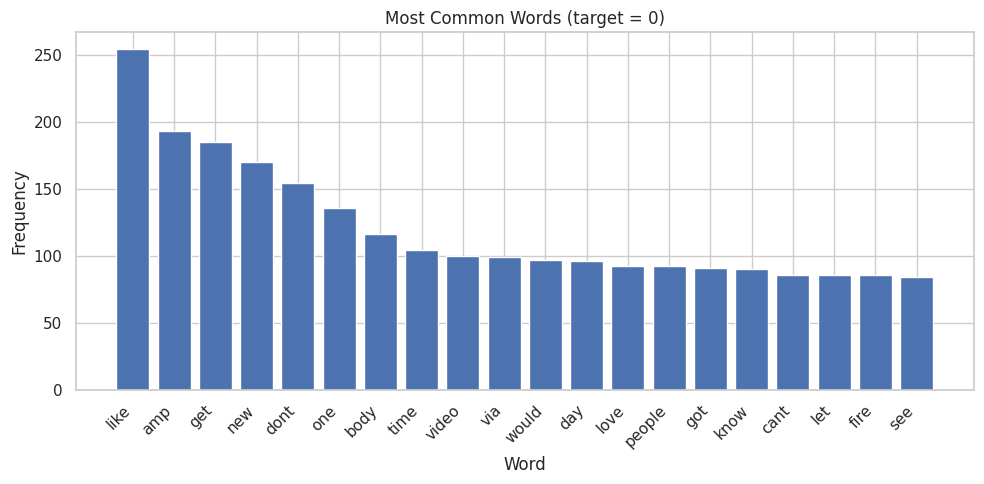

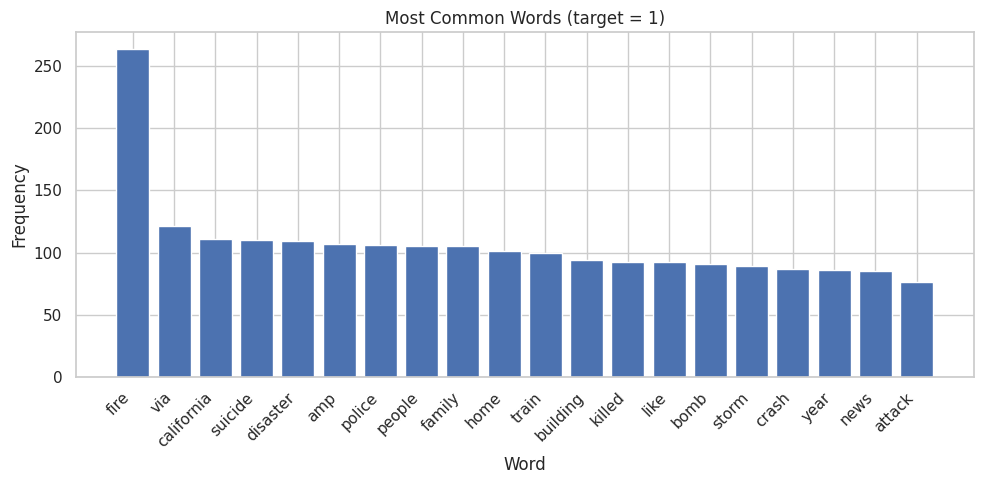

In [ ]:
for val in [0, 1]:
  # filter rows where target == val
  tokens_target_1 = train_data.loc[train_data["target"] == val, "tokens"]

  # flatten all token lists into one list
  all_tokens = [token for tokens in tokens_target_1 for token in tokens]

  # count word frequencies
  word_counts = Counter(all_tokens)

  # get most common words
  common_words = word_counts.most_common(20)  # top 20

  words, counts = zip(*common_words)

  plt.figure(figsize=(10, 5))
  plt.bar(words, counts)
  plt.xticks(rotation=45, ha="right")
  plt.xlabel("Word")
  plt.ylabel("Frequency")
  plt.title("Most Common Words (target = "+str(val)+")")
  plt.tight_layout()
  plt.show()

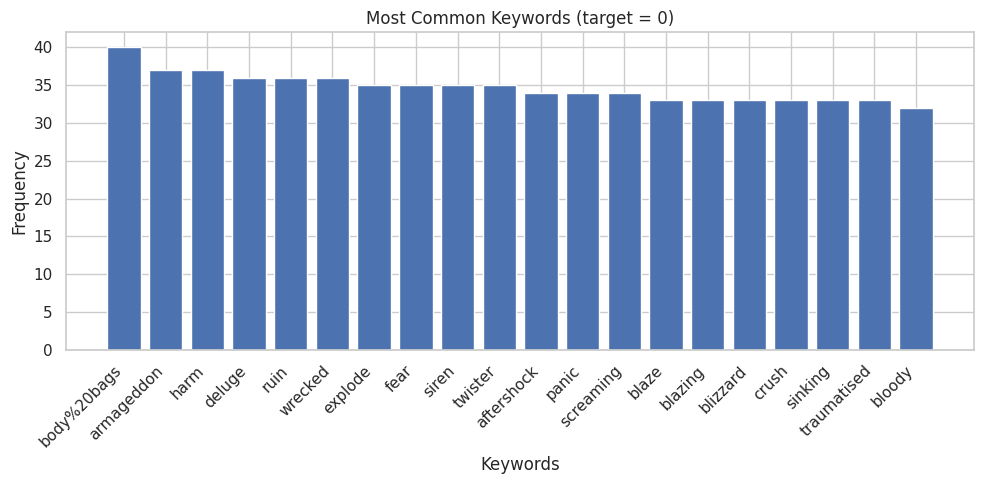

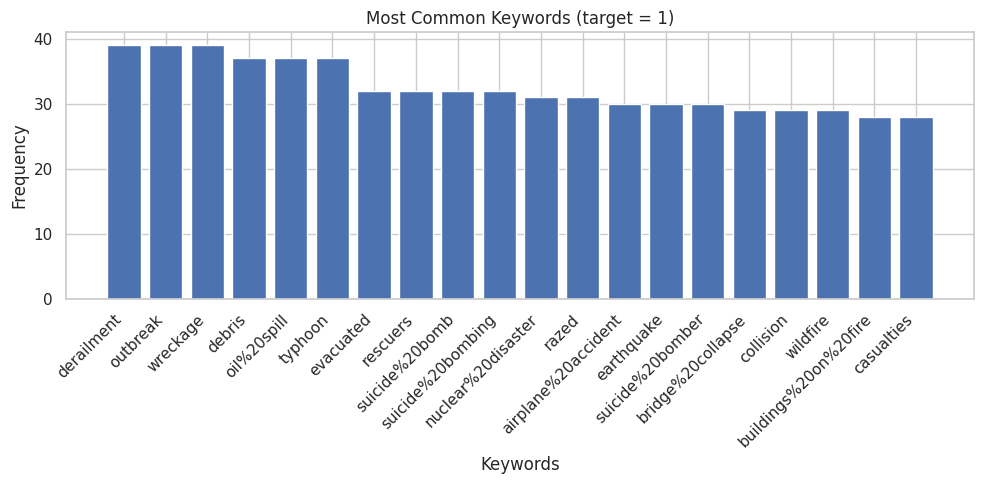

In [ ]:
for val in [0, 1]:
    # filter rows where target == val
    keywords_target = train_data.loc[train_data["target"] == val, "keyword"]

    # drop NaNs and force strings
    keywords_target = keywords_target.dropna().astype(str)

    keyword_counts = Counter(keywords_target)
    common_keywords = keyword_counts.most_common(20)

    if common_keywords:
      keywords, counts = zip(*common_keywords)

      plt.figure(figsize=(10, 5))
      plt.bar(keywords, counts)
      plt.xticks(rotation=45, ha="right")
      plt.xlabel("Keywords")
      plt.ylabel("Frequency")
      plt.title(f"Most Common Keywords (target = {val})")
      plt.tight_layout()
      plt.show()

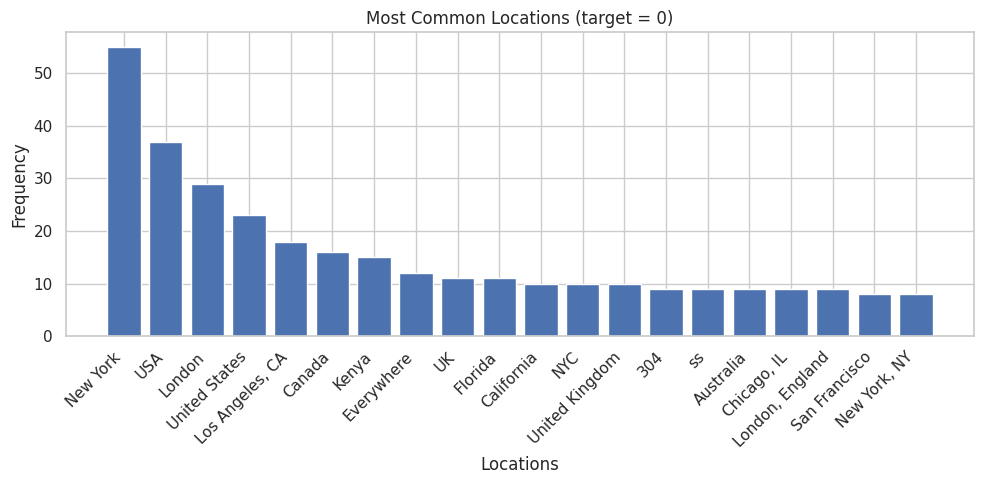

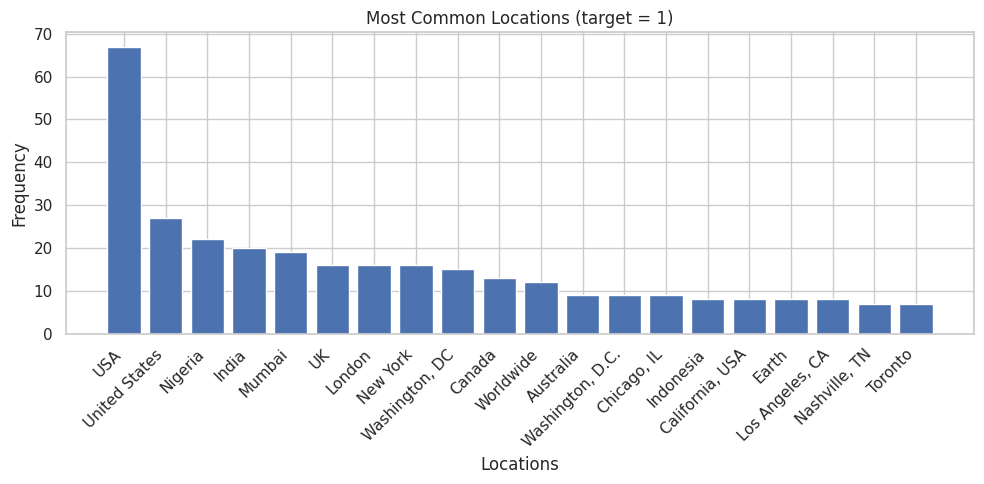

In [ ]:
for val in [0, 1]:
    # filter rows where target == val
    locations_target = train_data.loc[train_data["target"] == val, "location"]

    # drop NaNs and force strings
    locations_target = locations_target.dropna().astype(str)

    location_counts = Counter(locations_target)
    common_locations = location_counts.most_common(20)

    if common_locations:
      locations, counts = zip(*common_locations)

      plt.figure(figsize=(10, 5))
      plt.bar(locations, counts)
      plt.xticks(rotation=45, ha="right")
      plt.xlabel("Locations")
      plt.ylabel("Frequency")
      plt.title(f"Most Common Locations (target = {val})")
      plt.tight_layout()
      plt.show()

# Text Vectorization

In [ ]:
# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Fit and transform the train data, transform the test data
X_train = tfidf.fit_transform(train_data['cleaned_text'])
X_test = tfidf.transform(test_data['cleaned_text'])

# Target variable (labels) for training
y_train = train_data['target']

# Determining the Best Model


Logistic
[[783  91]
 [217 432]]
               precision    recall  f1-score   support

Fake Disaster       0.78      0.90      0.84       874
Real Disaster       0.83      0.67      0.74       649

     accuracy                           0.80      1523
    macro avg       0.80      0.78      0.79      1523
 weighted avg       0.80      0.80      0.79      1523


DecisionTree
[[860  14]
 [517 132]]
               precision    recall  f1-score   support

Fake Disaster       0.62      0.98      0.76       874
Real Disaster       0.90      0.20      0.33       649

     accuracy                           0.65      1523
    macro avg       0.76      0.59      0.55      1523
 weighted avg       0.74      0.65      0.58      1523


RandomForest
[[711 163]
 [198 451]]
               precision    recall  f1-score   support

Fake Disaster       0.78      0.81      0.80       874
Real Disaster       0.73      0.69      0.71       649

     accuracy                           0.76      1523
    m

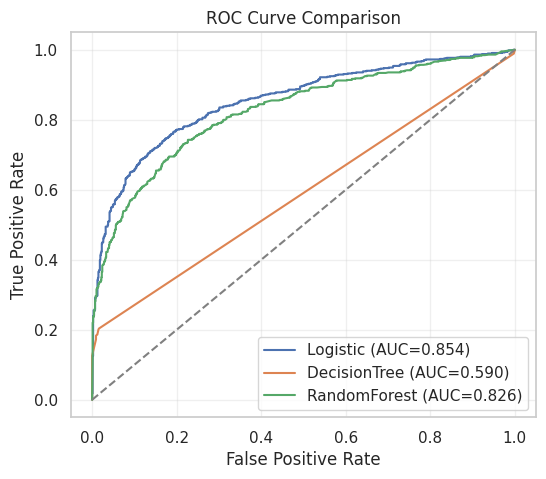

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic,0.797768,0.826004,0.665639,0.737201
1,DecisionTree,0.651346,0.904110,0.203390,0.332075
2,RandomForest,0.762968,0.734528,0.694915,0.714173


In [ ]:
# Pipelines for each model
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

pipelines = {
    'Logistic': Pipeline([
        ('model', LogisticRegression(max_iter=1000))
    ]),
    'DecisionTree': Pipeline([
        ('model', DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=3,
            class_weight='balanced',
            random_state=42
        ))
    ]),
    'RandomForest': Pipeline([
        ('model', RandomForestClassifier(random_state=42, n_estimators=100))
    ]),
}

# Evaluate each model
results = []
for name, pipe in pipelines.items():
    pipe.fit(X_train_split, y_train_split)
    y_pred = pipe.predict(X_val_split)
    acc = accuracy_score(y_val_split, y_pred)
    prec = precision_score(y_val_split, y_pred)
    rec = recall_score(y_val_split, y_pred)
    f1 = f1_score(y_val_split, y_pred)
    results.append([name, acc, prec, rec, f1])

    print(f"\n{name}")
    print(confusion_matrix(y_val_split, y_pred))
    print(classification_report(y_val_split, y_pred, target_names=["Fake Disaster", "Real Disaster"]))

# ROC curve comparison
plt.figure(figsize=(6,5))
for name, pipe in pipelines.items():
    y_prob = pipe.predict_proba(X_val_split)[:, 1]
    fpr, tpr, _ = roc_curve(y_val_split, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")

plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Summary table
df_results = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])
df_results

# Hyperparameter Tuning & Prediction

In [ ]:
RANDOM_STATE = 42

# Pipeline
logreg_pipe = Pipeline([
    ('model', LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        solver='liblinear'   # good for smaller datasets & binary classification
    ))
])

# Hyperparameters
param_grid = {
    'model__C': [0.01, 0.1, 1, 10]
}

# Cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Grid search
grid = GridSearchCV(
    logreg_pipe,
    param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Fit
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

# Train best model on full data
best_model = grid.best_estimator_
best_model.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'model__C': 1}
Best CV accuracy: 0.797582491158349


Pipeline(steps=[('model',
                 LogisticRegression(C=1, max_iter=1000, random_state=42,
                                    solver='liblinear'))])

In [ ]:
# Predict
kaggle_preds = best_model.predict(X_test)

# Submission
submission = pd.DataFrame({
    'id': test_data['id'].values,
    'target': kaggle_preds
})
submission.to_csv('submission.csv', index=False)

submission.head()

,id,target
0,0,1
1,2,0
2,3,1
3,9,0
4,11,1
